In [67]:
import json
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import (
    Input, Embedding, LSTM, Bidirectional, Dense, Dropout,
    LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D
)
from tensorflow.keras.models import Model

Arabic normalization

In [68]:
def normalize_arabic(text):
    text = str(text)

    # Remove tashkeel
    text = re.sub(r'[\u0617-\u061A\u064B-\u0652]', '', text)

    # Normalize Alef
    text = re.sub(r'[إأآا]', 'ا', text)

    # Normalize Ya
    text = re.sub(r'ى', 'ي', text)

    # Normalize Ta Marbuta
    text = re.sub(r'ة', 'ه', text)

    # Remove punctuation except Arabic/English letters and numbers
    text = re.sub(r'[^\w\s\u0600-\u06FF]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [69]:
def load_qa_json(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        raw = json.load(f)

    rows = []
    for article in raw.get("data", []):
        for paragraph in article.get("paragraphs", []):
            context = paragraph.get("context", "")
            for qa in paragraph.get("qas", []):
                question = qa.get("question", "")
                answers = qa.get("answers", [])
                answer_text = answers[0].get("text", "") if answers else ""

                rows.append({
                    "id": qa.get("id", ""),
                    "question": question,
                    "context": context,
                    "answer": answer_text
                })

    return rows

DATASET_DIR = "data_MS2"

train_rows = []
test_rows = []

for file in os.listdir(DATASET_DIR):
    if file.endswith(".json"):
        file_path = os.path.join(DATASET_DIR, file)

        if "test_set" in file:
            test_rows.extend(load_qa_json(file_path))
        elif "qa_dataset" in file:
            train_rows.extend(load_qa_json(file_path))

df = pd.DataFrame(train_rows)
test_df = pd.DataFrame(test_rows)

df = df.copy()

print("Training samples:", len(df))
print("Testing samples:", len(test_df))

df.head()

Training samples: 168
Testing samples: 72


,id,question,context,answer
0,Q1,ما الحدث الذي جعل أورسون ويلز مشهورًا قبل دخول...,في ليلة 30 أكتوبر 1938، انقطع بث إذاعي ليعلن ع...,تمثيلية إذاعية عن غزو فضائي
1,Q2,ما الرواية التي استندت إليها التمثيلية الإذاعية؟,بعد الذعر الجماهيري، اكتشف الناس أن القصة مقتب...,حرب العوالم
2,Q3,لماذا اهتمت هوليوود بأورسون ويلز؟,لاحظت هوليوود أن ويلز استطاع التأثير على ملايي...,قدرته على التأثير في مشاعر الجمهور باستخدام الصوت
3,Q4,ما طبيعة أفلام هوليوود قبل Citizen Kane؟,في تلك الفترة، اعتمدت أفلام هوليوود على قوالب ...,قوالب تقليدية ونهايات سعيدة
4,Q5,لماذا تجنبت هوليوود التجريب؟,بعد الكساد العظيم، كان الجمهور يبحث عن التسلية...,رغبة الجمهور في التسلية بعد الكساد العظيم


In [70]:
df["question_norm"] = df["question"].apply(normalize_arabic)
df["context_norm"] = df["context"].apply(normalize_arabic)
df["answer_norm"] = df["answer"].apply(normalize_arabic)

df["input_text"] = "[Q] " + df["question_norm"] + " [C] " + df["context_norm"]

df[["question_norm", "context_norm", "answer_norm", "input_text"]].head()

,question_norm,context_norm,answer_norm,input_text
0,ما الحدث الذي جعل اورسون ويلز مشهورا قبل دخوله...,في ليله 30 اكتوبر 1938، انقطع بث اذاعي ليعلن ع...,تمثيليه اذاعيه عن غزو فضائي,[Q] ما الحدث الذي جعل اورسون ويلز مشهورا قبل د...
1,ما الروايه التي استندت اليها التمثيليه الاذاعيه؟,بعد الذعر الجماهيري، اكتشف الناس ان القصه مقتب...,حرب العوالم,[Q] ما الروايه التي استندت اليها التمثيليه الا...
2,لماذا اهتمت هوليوود باورسون ويلز؟,لاحظت هوليوود ان ويلز استطاع التاثير علي ملايي...,قدرته علي التاثير في مشاعر الجمهور باستخدام الصوت,[Q] لماذا اهتمت هوليوود باورسون ويلز؟ [C] لاحظ...
3,ما طبيعه افلام هوليوود قبل Citizen Kane؟,في تلك الفتره، اعتمدت افلام هوليوود علي قوالب ...,قوالب تقليديه ونهايات سعيده,[Q] ما طبيعه افلام هوليوود قبل Citizen Kane؟ [...
4,لماذا تجنبت هوليوود التجريب؟,بعد الكساد العظيم، كان الجمهور يبحث عن التسليه...,رغبه الجمهور في التسليه بعد الكساد العظيم,[Q] لماذا تجنبت هوليوود التجريب؟ [C] بعد الكسا...


Find start/end word positions

In [71]:
def find_answer_token_positions(context, answer):
    context_tokens = context.split()
    answer_tokens = answer.split()

    for i in range(len(context_tokens) - len(answer_tokens) + 1):
        if context_tokens[i:i+len(answer_tokens)] == answer_tokens:
            start = i
            end = i + len(answer_tokens) - 1
            return start, end

    return None, None


starts = []
ends = []

for _, row in df.iterrows():
    start, end = find_answer_token_positions(row["context_norm"], row["answer_norm"])
    starts.append(start)
    ends.append(end)

df["start_pos"] = starts
df["end_pos"] = ends

df[["context_norm", "answer_norm", "start_pos", "end_pos"]].head()

,context_norm,answer_norm,start_pos,end_pos
0,في ليله 30 اكتوبر 1938، انقطع بث اذاعي ليعلن ع...,تمثيليه اذاعيه عن غزو فضائي,NaN,NaN
1,بعد الذعر الجماهيري، اكتشف الناس ان القصه مقتب...,حرب العوالم,NaN,NaN
2,لاحظت هوليوود ان ويلز استطاع التاثير علي ملايي...,قدرته علي التاثير في مشاعر الجمهور باستخدام الصوت,NaN,NaN
3,في تلك الفتره، اعتمدت افلام هوليوود علي قوالب ...,قوالب تقليديه ونهايات سعيده,NaN,NaN
4,بعد الكساد العظيم، كان الجمهور يبحث عن التسليه...,رغبه الجمهور في التسليه بعد الكساد العظيم,NaN,NaN


Remove unmatched samples and correction for positions

In [72]:
print("Before removing unmatched:", len(df))

df = df.dropna(subset=["start_pos", "end_pos"]).copy()

df["start_pos"] = df["start_pos"].astype(int)
df["end_pos"] = df["end_pos"].astype(int)

print("After removing unmatched:", len(df))

Before removing unmatched: 168
After removing unmatched: 61


In [73]:
def get_context_offset(question):
    return len(("[Q] " + question + " [C]").split())

df["context_offset"] = df["question_norm"].apply(get_context_offset)

df["start_label"] = df["start_pos"] + df["context_offset"]
df["end_label"] = df["end_pos"] + df["context_offset"]

df[["input_text", "answer_norm", "start_label", "end_label"]].head()

,input_text,answer_norm,start_label,end_label
11,[Q] ما الاسلوب السردي؟ [C] يعتمد الفيلم علي ال...,السرد غير الخطي,8,10
17,[Q] كيف استخدمت الاضاءه؟ [C] تم استخدام الضوء ...,لابراز الحاله النفسيه,9,11
24,[Q] ما معني Rosebud؟ [C] في النهايه، يتم الكشف...,الطفوله والبراءه المفقوده,13,15
28,[Q] الي اين كانت رحله الاختبار للطائره؟ [C] مط...,من المصنع لقاعده موجوده في فلوريدا,17,22
29,[Q] لماذا كانت تجربه الطائره حساسه اعلاميا؟ [C...,ممكن تاثر علي مبيعات لوكهيد مارتن، ودي مبيعات ...,19,28


Tokenize and pad

In [74]:
MAX_LEN = 256
VOCAB_SIZE = 10000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="[UNK]")
tokenizer.fit_on_texts(df["input_text"])

sequences = tokenizer.texts_to_sequences(df["input_text"])

X = pad_sequences(sequences, maxlen=MAX_LEN, padding="post", truncating="post")

y_start = df["start_label"].values
y_end = df["end_label"].values

valid_indices = (y_start < MAX_LEN) & (y_end < MAX_LEN)

X = X[valid_indices]
y_start = y_start[valid_indices]
y_end = y_end[valid_indices]

print(X.shape, y_start.shape, y_end.shape)

(61, 256) (61,) (61,)


Train/validation/test split

In [75]:
# Split training data into train and validation
X_train, X_val, y_start_train, y_start_val, y_end_train, y_end_val = train_test_split(
    X,
    y_start,
    y_end,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)

Train: (48, 256)
Validation: (13, 256)


In [76]:
# Process held-out test set
test_df = test_df.copy()

test_df["question_norm"] = test_df["question"].apply(normalize_arabic)
test_df["context_norm"] = test_df["context"].apply(normalize_arabic)
test_df["answer_norm"] = test_df["answer"].apply(normalize_arabic)

starts = []
ends = []

for _, row in test_df.iterrows():
    start, end = find_answer_token_positions(row["context_norm"], row["answer_norm"])
    starts.append(start)
    ends.append(end)

test_df["start_pos"] = starts
test_df["end_pos"] = ends

# Drop rows where answer was not found BEFORE tokenizing
test_df = test_df.dropna(subset=["start_pos", "end_pos"]).copy()

test_df["start_pos"] = test_df["start_pos"].astype(int)
test_df["end_pos"] = test_df["end_pos"].astype(int)

test_df["input_text"] = "[Q] " + test_df["question_norm"] + " [C] " + test_df["context_norm"]

test_df["context_offset"] = test_df["question_norm"].apply(get_context_offset)

test_df["start_label"] = test_df["start_pos"] + test_df["context_offset"]
test_df["end_label"] = test_df["end_pos"] + test_df["context_offset"]

# Keep only valid labels inside MAX_LEN
test_df = test_df[
    (test_df["start_label"] < MAX_LEN) &
    (test_df["end_label"] < MAX_LEN)
].copy()

# Now tokenize AFTER all filtering
test_sequences = tokenizer.texts_to_sequences(test_df["input_text"])
X_test = pad_sequences(test_sequences, maxlen=MAX_LEN, padding="post", truncating="post")

y_start_test = test_df["start_label"].values
y_end_test = test_df["end_label"].values


In [77]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)
print("y_start_test:", y_start_test.shape)
print("y_end_test:", y_end_test.shape)

Train: (48, 256)
Validation: (13, 256)
Test: (34, 256)
y_start_test: (34,)
y_end_test: (34,)


BiLSTM Extractive QA Model

In [78]:
def build_bilstm_qa_model(vocab_size, max_len, embedding_dim=128):
    inputs = Input(shape=(max_len,))

    x = Embedding(vocab_size, embedding_dim, mask_zero=False)(inputs)

    x = Bidirectional(LSTM(128, return_sequences=True))(x)
    x = Dropout(0.3)(x)

    x = Bidirectional(LSTM(64, return_sequences=True))(x)
    x = Dropout(0.3)(x)

    start_output = Dense(1, activation=None)(x)
    start_output = tf.keras.layers.Reshape((max_len,))(start_output)
    start_output = tf.keras.layers.Activation("softmax", name="start_output")(start_output)

    end_output = Dense(1, activation=None)(x)
    end_output = tf.keras.layers.Reshape((max_len,))(end_output)
    end_output = tf.keras.layers.Activation("softmax", name="end_output")(end_output)

    model = Model(inputs=inputs, outputs=[start_output, end_output])

    model.compile(
        optimizer="adam",
        loss={
            "start_output": "sparse_categorical_crossentropy",
            "end_output": "sparse_categorical_crossentropy"
        },
        metrics={
            "start_output": "accuracy",
            "end_output": "accuracy"
        }
    )

    return model


bilstm_model = build_bilstm_qa_model(VOCAB_SIZE, MAX_LEN)
bilstm_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_6         │ (None, 256, 128)  │  1,280,000 │ input_layer_4[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_4     │ (None, 256, 256)  │    263,168 │ embedding_6[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 256, 256)  │          0 │ bidirectional_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_5     │ (None, 256, 128)  │    164,352 │ dropout_8[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 256, 128)  │          0 │ bidirectional_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 256, 1)    │        129 │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 256, 1)    │        129 │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_8 (Reshape) │ (None, 256)       │          0 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_9 (Reshape) │ (None, 256)       │          0 │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ start_output        │ (None, 256)       │          0 │ reshape_8[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ end_output          │ (None, 256)       │          0 │ reshape_9[0][0]   │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,707,778 (6.51 MB)

 Trainable params: 1,707,778 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

In [79]:
history_bilstm = bilstm_model.fit(
    X_train,
    {
        "start_output": y_start_train,
        "end_output": y_end_train
    },
    validation_data=(
        X_val,
        {
            "start_output": y_start_val,
            "end_output": y_end_val
        }
    ),
    epochs=10,
    batch_size=16
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - end_output_accuracy: 0.0000e+00 - end_output_loss: 5.4481 - loss: 10.8808 - start_output_accuracy: 0.0000e+00 - start_output_loss: 5.4327 - val_end_output_accuracy: 0.0000e+00 - val_end_output_loss: 4.8751 - val_loss: 9.5796 - val_start_output_accuracy: 0.0000e+00 - val_start_output_loss: 4.7044
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 600ms/step - end_output_accuracy: 0.0000e+00 - end_output_loss: 4.6441 - loss: 9.0803 - start_output_accuracy: 0.0000e+00 - start_output_loss: 4.4363 - val_end_output_accuracy: 0.1538 - val_end_output_loss: 3.6579 - val_loss: 7.1536 - val_start_output_accuracy: 0.0000e+00 - val_start_output_loss: 3.4957
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 646ms/step - end_output_accuracy: 0.0443 - end_output_loss: 3.5616 - loss: 7.0321 - start_output_accuracy: 0.0182 - start_output_loss: 3.4705 - val_end_output_accuracy: 0.1538 - val_end_output_loss: 2.9241 - val_loss: 5.8936 - val_start_output_accuracy: 0.1538 - val_sta

Transformer Extractive QA Model

In [80]:
class TokenAndPositionEmbedding(tf.keras.layers.Layer):
    def __init__(self, max_len, vocab_size, embedding_dim):
        super().__init__()
        self.token_emb = Embedding(input_dim=vocab_size, output_dim=embedding_dim)
        self.pos_emb = Embedding(input_dim=max_len, output_dim=embedding_dim)

    def call(self, x):
        positions = tf.range(start=0, limit=tf.shape(x)[-1], delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

In [81]:
def build_transformer_qa_model(vocab_size, max_len, embedding_dim=128, num_heads=4, ff_dim=128):
    inputs = Input(shape=(max_len,))

    x = TokenAndPositionEmbedding(max_len, vocab_size, embedding_dim)(inputs)

    attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=embedding_dim)(x, x)
    x = LayerNormalization(epsilon=1e-6)(x + attention_output)

    ffn = Dense(ff_dim, activation="relu")(x)
    ffn = Dense(embedding_dim)(ffn)
    x = LayerNormalization(epsilon=1e-6)(x + ffn)

    x = Dropout(0.3)(x)

    start_output = Dense(1, activation=None)(x)
    start_output = tf.keras.layers.Reshape((max_len,))(start_output)
    start_output = tf.keras.layers.Activation("softmax", name="start_output")(start_output)

    end_output = Dense(1, activation=None)(x)
    end_output = tf.keras.layers.Reshape((max_len,))(end_output)
    end_output = tf.keras.layers.Activation("softmax", name="end_output")(end_output)

    model = Model(inputs=inputs, outputs=[start_output, end_output])

    model.compile(
        optimizer="adam",
        loss={
            "start_output": "sparse_categorical_crossentropy",
            "end_output": "sparse_categorical_crossentropy"
        },
        metrics={
            "start_output": "accuracy",
            "end_output": "accuracy"
        }
    )

    return model


transformer_model = build_transformer_qa_model(VOCAB_SIZE, MAX_LEN)
transformer_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_and_position… │ (None, 256, 128)  │  1,312,768 │ input_layer_5[0]… │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 256, 128)  │    263,808 │ token_and_positi… │
│ (MultiHeadAttentio… │                   │            │ token_and_positi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 256, 128)  │          0 │ token_and_positi… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 128)  │        256 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 256, 128)  │     16,512 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 256, 128)  │     16,512 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 256, 128)  │          0 │ layer_normalizat… │
│                     │                   │            │ dense_15[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 128)  │        256 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 256, 128)  │          0 │ layer_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 256, 1)    │        129 │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 256, 1)    │        129 │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_10          │ (None, 256)       │          0 │ dense_16[0][0]    │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_11          │ (None, 256)       │          0 │ dense_17[0][0]    │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ start_output        │ (None, 256)       │          0 │ reshape_10[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ end_output          │ (None, 256)       │          0 │ reshape_11[0][0]  │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,610,370 (6.14 MB)

 Trainable params: 1,610,370 (6.14 MB)

 Non-trainable params: 0 (0.00 B)

In [82]:
history_transformer = transformer_model.fit(
    X_train,
    {
        "start_output": y_start_train,
        "end_output": y_end_train
    },
    validation_data=(
        X_val,
        {
            "start_output": y_start_val,
            "end_output": y_end_val
        }
    ),
    epochs=10,
    batch_size=16
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 658ms/step - end_output_accuracy: 0.0000e+00 - end_output_loss: 6.6466 - loss: 11.4372 - start_output_accuracy: 0.0208 - start_output_loss: 4.7907 - val_end_output_accuracy: 0.0000e+00 - val_end_output_loss: 3.2893 - val_loss: 6.8170 - val_start_output_accuracy: 0.0769 - val_start_output_loss: 3.5277
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 281ms/step - end_output_accuracy: 0.2786 - end_output_loss: 2.4251 - loss: 4.7909 - start_output_accuracy: 0.2161 - start_output_loss: 2.3658 - val_end_output_accuracy: 0.0000e+00 - val_end_output_loss: 3.0670 - val_loss: 6.1969 - val_start_output_accuracy: 0.0000e+00 - val_start_output_loss: 3.1300
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 285ms/step - end_output_accuracy: 0.2604 - end_output_loss: 2.1985 - loss: 4.1990 - start_output_accuracy: 0.3880 - start_output_loss: 2.0005 - val_end_output_accuracy: 0.0769 - val_end_output_loss: 3.0940 - val_loss: 6.3729 - val_start_output_accuracy: 0.0000e+00 - val_start_out

Plot curves

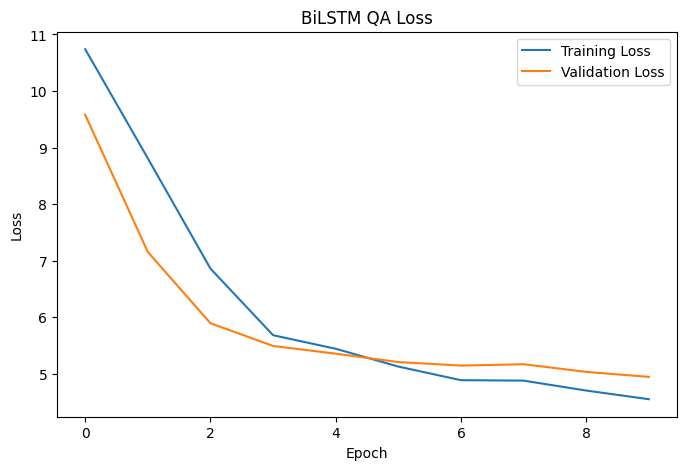

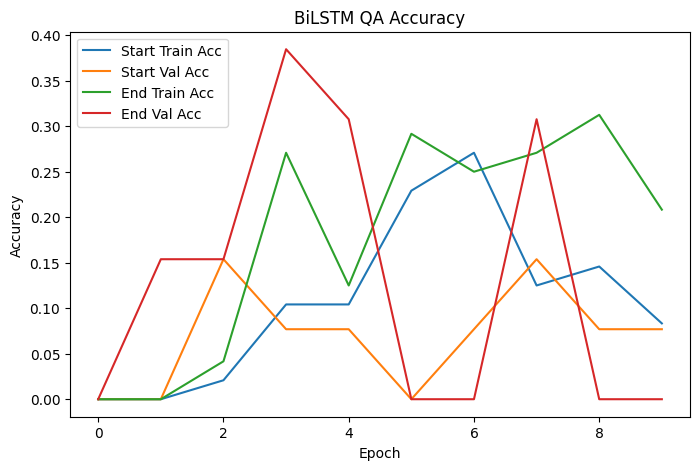

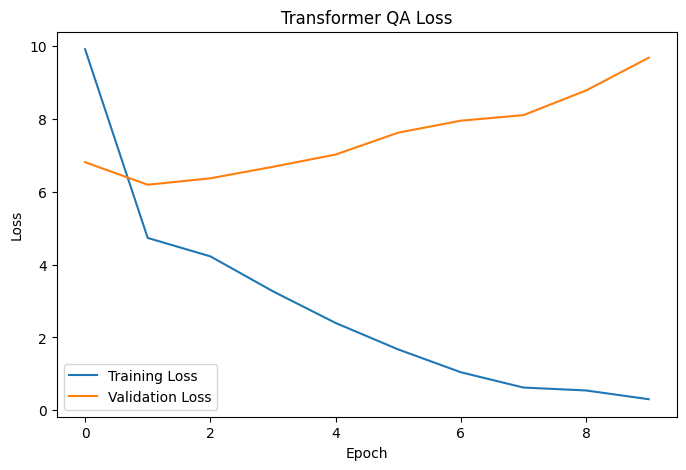

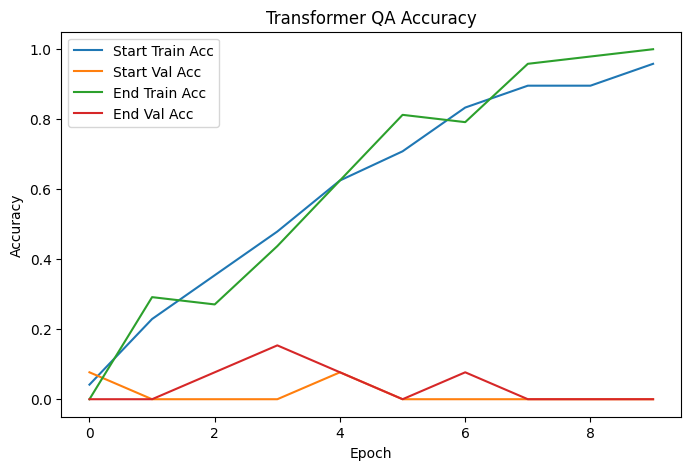

In [83]:
def plot_history(history, title):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(title + " Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history.history["start_output_accuracy"], label="Start Train Acc")
    plt.plot(history.history["val_start_output_accuracy"], label="Start Val Acc")
    plt.plot(history.history["end_output_accuracy"], label="End Train Acc")
    plt.plot(history.history["val_end_output_accuracy"], label="End Val Acc")
    plt.title(title + " Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()


plot_history(history_bilstm, "BiLSTM QA")
plot_history(history_transformer, "Transformer QA")

Evaluate both models

In [84]:
print("BiLSTM Evaluation:")
bilstm_model.evaluate(
    X_test,
    {
        "start_output": y_start_test,
        "end_output": y_end_test
    }
)

print("Transformer Evaluation:")
transformer_model.evaluate(
    X_test,
    {
        "start_output": y_start_test,
        "end_output": y_end_test
    }
)

BiLSTM Evaluation:
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - end_output_accuracy: 0.0496 - end_output_loss: 1.9761 - loss: 4.5884 - start_output_accuracy: 0.1201 - start_output_loss: 2.6229
Transformer Evaluation:
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - end_output_accuracy: 0.5300 - end_output_loss: 2.0116 - loss: 5.0962 - start_output_accuracy: 0.4504 - start_output_loss: 2.9263 


[5.085635662078857,
 2.9047698974609375,
 1.9434454441070557,
 0.529411792755127,
 0.44117647409439087]

Inference function

In [85]:
def predict_answer(question, context, model, tokenizer, max_len=256):
    question_norm = normalize_arabic(question)
    context_norm = normalize_arabic(context)

    input_text = "[Q] " + question_norm + " [C] " + context_norm

    seq = tokenizer.texts_to_sequences([input_text])
    padded = pad_sequences(seq, maxlen=max_len, padding="post", truncating="post")

    start_probs, end_probs = model.predict(padded)

    context_offset = len(("[Q] " + question_norm + " [C]").split())

    # Prevent model from choosing tokens from [Q] or the question
    start_probs[0][:context_offset] = 0
    end_probs[0][:context_offset] = 0

    tokens = input_text.split()

    # Also prevent choosing padding / positions after real tokens
    start_probs[0][len(tokens):] = 0
    end_probs[0][len(tokens):] = 0

    start_idx = np.argmax(start_probs[0])
    end_idx = np.argmax(end_probs[0])

    if end_idx < start_idx:
        end_idx = start_idx

    predicted_tokens = tokens[start_idx:end_idx + 1]
    predicted_answer = " ".join(predicted_tokens)

    return predicted_answer, start_idx, end_idx

In [86]:
sample = df.iloc[0]

answer, start, end = predict_answer(
    sample["question"],
    sample["context"],
    bilstm_model,
    tokenizer,
    MAX_LEN
)

print("Question:", sample["question"])
print("True Answer:", sample["answer"])
print("Predicted Answer:", answer)
print("Start:", start)
print("End:", end)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Question: ما الأسلوب السردي؟
True Answer: السرد غير الخطي
Predicted Answer: الماضي والحاضر هذا يجعل القصه اكثر
Start: 14
End: 19


In [87]:

sample = df.iloc[10]

answer, start, end = predict_answer(
    sample["question"],
    sample["context"],
    transformer_model,
    tokenizer,
    MAX_LEN
)

print("Question:", sample["question"])
print("True Answer:", sample["answer"])
print("Predicted Answer:", answer)
print("Start:", start)
print("End:", end)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step
Question: إلى أي شعبة ينتمي الأخطبوط؟
True Answer: الرخويات
Predicted Answer: الرخويات
Start: 9
End: 9
